# 通信会社の顧客離反（チャーン）予測

## 背景と目的
通信会社の顧客データ（約7,000件）から「来月解約しそうな顧客」を予測し、
解約しそうな顧客に施策を打つことで離反を防ぐ。
単なる予測に留めず、「誰に・なぜ・どんな施策を打つべきか」まで導くことを目的とする。

## 使用データ
Telco Customer Churn（Kaggle）: 顧客属性・契約内容・利用サービス・料金・解約有無（21項目）

## 使用技術
Python / pandas / scikit-learn / XGBoost、実行環境: AWS SageMaker Studio

## 分析の流れ
1. データ理解とクリーニング（EDA・前処理）
2. 複数モデルの比較（ベースライン〜勾配ブースティング）
3. クラス不均衡への対処（重み付け・閾値調整）
4. 解約要因の可視化（SHAP）と施策提案

## Telco Customer Churn データセットとは
・架空の通信会社の顧客データで、「どんな顧客が解約(churn)したか」を分析・予測するための教材用データセット

## 顧客の属性

・customerID … 顧客の識別番号

・gender / SeniorCitizen(高齢者か) / Partner(配偶者の有無) / Dependents(扶養家族の有無)

## 契約・期間まわり(解約予測で特に効く)

・tenure … 契約してからの継続月数。短いほど解約しやすい傾向

・Contract … 契約タイプ(Month-to-month 月契約 / One year / Two year)

・PaperlessBilling(ペーパーレス請求か) / PaymentMethod(支払い方法)

## 利用しているサービス

・PhoneService / MultipleLines(電話・複数回線)

・InternetService(DSL / 光ファイバー / なし)

・OnlineSecurity / OnlineBackup / DeviceProtection / TechSupport / StreamingTV / StreamingMovies(各種オプションサービスの加入有無)

## 料金

・MonthlyCharges … 月額料金

・TotalCharges … 累計支払額

## 目的変数

・Churn … 解約したか(Yes / No)

## 0. セットアップ（ライブラリ、データセットの読み込み）

In [39]:
# --- 基本（データ操作・数値計算） ---
import numpy as np
import pandas as pd

# --- 前処理・データ分割 ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# --- モデル ---
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# --- 評価 ---
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, precision_recall_curve

# --- 可視化・モデル解釈 ---
# !pip install shap
import matplotlib.pyplot as plt
import seaborn as sns
import shap

## 1. データ理解と探索的データ分析（EDA）

まずデータの素性を把握し、解約とどの特徴量が関係しそうか仮説を立てる。

### 確認すること
- 各特徴量の分布（数値・カテゴリ）
- 目的変数 `Churn`（解約）の割合 → クラスの偏りを把握
- 契約タイプ・継続月数などと解約の関係

In [40]:
# 今回使うデータセットの読み込み
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### データの読み込み
Kaggleの Telco Customer Churn データ（CSV）を読み込む。
1行が1顧客に対応し、顧客ID・属性・契約内容・利用サービス・料金・解約有無（`Churn`）の列を持つ。

In [41]:
# データの大きさの確認
print(df.shape)

(7043, 21)


### データの規模
7,043人の顧客 × 21項目のデータ。1項目が目的変数（Churn）、残り20項目が予測に使える特徴量。
分析には扱いやすいサイズ。

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### 型の確認で見つかった問題
- `TotalCharges` が数値ではなく **object型（文字列）** になっている
- 本来は金額なので数値のはず
- 原因：一部の行に空白（" "）が混入 → pandasが列全体を文字列と判定
- 対応：前処理で数値型に変換し、欠損を処理する（後述）

### 解約と各特徴量の関係を確認
- 予測対象（Churn）の偏りと、解約に効きそうな要因を探る

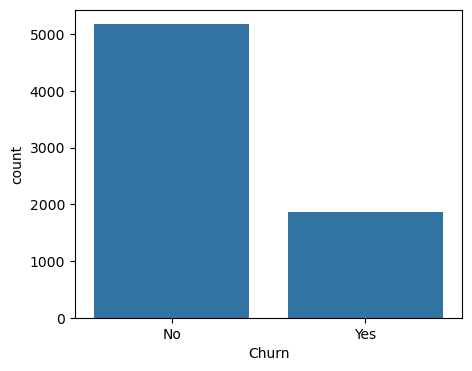

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


In [43]:
# ① まず予測対象（Churn）の分布と割合を確認
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x="Churn", data=df, ax=ax)
plt.show()
print(df["Churn"].value_counts(normalize=True))

→ 解約は約27%で少数派（クラス不均衡あり）

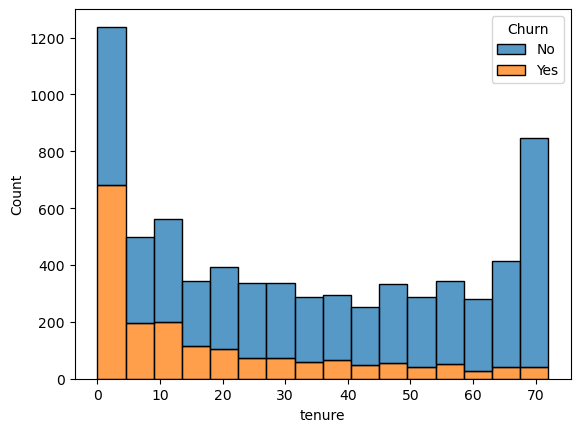

In [44]:
# ② 継続月数（tenure）と解約の関係
sns.histplot(data=df, x="tenure", hue="Churn", multiple="stack")
plt.show()

→ 継続月数が短い顧客ほど解約が多い

In [45]:
# ③ 契約タイプ（Contract）と解約の関係（件数）
pd.crosstab(df["Contract"], df["Churn"])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


→ 各契約タイプの解約者数。ただし契約タイプで顧客数が違うため、次に「割合（解約率）」で比較する

In [46]:
# ④ 契約タイプ別の解約率（割合）
pd.crosstab(df["Contract"], df["Churn"], normalize="index")

Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


→ 月契約の解約率が突出して高い（契約が長いほど解約は減る）

### EDAのまとめ
- 解約者は約27% → クラス不均衡あり（評価指標の工夫が必要）
- 継続月数の短さ・月契約が、解約の強い予兆
- → これらを踏まえてモデルを構築・比較していく

## 2. データの前処理

- EDAで見つかった問題を修正し、モデルに入れられる形に整える
- 主な作業：型変換・欠損処理・目的変数の作成・カテゴリのダミー化・データ分割

In [47]:
# 「累計支払額」の値を文字列型から数値型に変換
# to_numericでerrors="coerce"を指定することで、数値型に変換できない値(スペース、空文字)をNaNに変換
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"]

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

### 型変換：TotalCharges
- 文字列になっていた `TotalCharges` を数値型に変換
- `errors="coerce"`：数値化できない空白・空文字を **NaN（欠損）** に変換
- → 変換後、空白だった行が欠損として表面化する（次のセルで件数を確認）

In [48]:
# 欠損値の数→元々空白だった数を確認
print(df['TotalCharges'].isnull().sum())

11


### 欠損の確認
- 型変換でNaNになった件数を確認 → **11件**
- これが「元々空白だった行」の数
- 全体（7,043件）に対してごく少数
- → 行を削除せず、中央値で補完する方針とする

In [49]:
# 中央値で補完（金額は外れ値の影響を受けにくい中央値を採用）
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

### 欠損の補完
- 11件の欠損を **中央値** で補完
- 平均でなく中央値を使う理由：金額は外れ値（極端に高い人）に引っ張られやすいため
- → `TotalCharges` の欠損がゼロになり、モデルに投入可能な状態に

### モデル用データの準備
- 目的変数 `y`：解約を 1／継続を 0 に変換
- 特徴量 `X`：不要な列（customerID・Churn）を除外し、カテゴリをダミー変数化
- 訓練・テストに分割（層化抽出で解約比率を保つ）

In [50]:
# 目的変数の作成・不要列の除外・ダミー化・データ分割

# df["Churn"] == "Yes"→出力をTrue/Falseの二値へ
# astype(int)で出力をTrueなら1、Falseなら0
y = (df["Churn"] == "Yes").astype(int)
# 不要な列を落とす → Churnは目的変数なので、対象としない。CustomerIDはただの顧客IDで数値そのものに意味がないから、学習の邪魔になる。
X = df.drop(columns=["customerID", "Churn"])
# カテゴリ変数をダミー変数化
X = pd.get_dummies(X, drop_first=True)

# stratify=y → 今のy(df["Churn"])の比率を訓練データ、テストデータでも保つ
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 解約率の平均を見る
print(f"訓練データの解約率: {y_train.mean():.4f}")
print(f"テストデータの解約率: {y_test.mean():.4f}")

訓練データの解約率: 0.2654
テストデータの解約率: 0.2654


→ 訓練・テストとも解約率が約0.27で一致 → 層化抽出（stratify）が効いている

## 3. モデルの構築と比較

- 複数の分類モデルを比較し、このデータに適したモデルを見極める
- まずシンプルなベースライン（ロジスティック回帰・決定木・SVM・KNN）から

### ベースラインモデルの比較
- いきなり複雑なモデルを使わず、まず基本的な4モデルで基準を作る
- 評価は accuracy ではなく、**解約（=1）の recall / precision / f1** に注目
  - 理由：解約者は少数派（約27%）。全員「継続」と予測しても73%の精度が出てしまうため
- SVM・KNN は距離ベースのため標準化（StandardScaler）を適用

In [51]:
# ベースとなるモデルで予測精度を見る

# ロジスティック回帰、決定木、SVM、KNNで算出
models = {
    "ロジスティック回帰(標準化)": make_pipeline(StandardScaler(),LogisticRegression(max_iter = 1000)),
    "決定木(剪定あり)": DecisionTreeClassifier(max_depth=5, random_state=42),
    "SVM(標準化)": make_pipeline(StandardScaler(), SVC()),
    "KNN(標準化)": make_pipeline(StandardScaler(), KNeighborsClassifier()),
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results.append({
        "モデル": name,
        "precision(解約)": round(precision_score(y_test, y_pred), 3),
        "recall(解約)":    round(recall_score(y_test, y_pred), 3),
        "f1(解約)":        round(f1_score(y_test, y_pred), 3),
    })

# f1の高い順に並べて表示
results_df = pd.DataFrame(results).sort_values("f1(解約)", ascending=False)
results_df

,モデル,precision(解約),recall(解約),f1(解約)
0,ロジスティック回帰(標準化),0.658,0.567,0.609
1,決定木(剪定あり),0.630,0.545,0.585
2,SVM(標準化),0.644,0.489,0.556
3,KNN(標準化),0.525,0.500,0.512


### 結果からわかること
- 解約（=1）の f1 は、ロジスティック回帰が最良（約0.60）
- 決定木・SVM・KNN はいずれもロジスティック回帰を上回らなかった
- 意外な発見：**シンプルな線形モデルが健闘**
  - このデータは特徴量と解約の関係が線形寄りのため
- どのモデルも解約 recall は 0.5前後で頭打ち → クラス不均衡が影響
- → 次に、より強力な勾配ブースティングを試す

### 勾配ブースティングモデルの比較
- ベースラインを踏まえ、表形式データに強い勾配ブースティング3種を試す
- XGBoost・LightGBM・CatBoost（いずれも決定木を束ねた手法）
- ベースライン最良（ロジスティック回帰）を超えられるかに注目

In [52]:
# 勾配ブースティングモデルで実装する
models = {
    "XGBoost":  XGBClassifier(eval_metric='logloss', random_state=42),
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1),
    "CatBoost": CatBoostClassifier(random_state=42, verbose=0),
}
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results.append({
        "モデル": name,
        "precision(解約)": round(precision_score(y_test, y_pred), 3),
        "recall(解約)":    round(recall_score(y_test, y_pred), 3),
        "f1(解約)":        round(f1_score(y_test, y_pred), 3),
    })

# f1の高い順に並べて表示
results_df = pd.DataFrame(results).sort_values("f1(解約)", ascending=False)
results_df

,モデル,precision(解約),recall(解約),f1(解約)
1,LightGBM,0.650,0.545,0.593
2,CatBoost,0.657,0.527,0.585
0,XGBoost,0.602,0.527,0.562


### 結果からわかること
- 3種とも解約f1は 0.56〜0.59 程度
- **ベースライン最良のロジスティック回帰（f1 0.60）を超えられなかった**
- 理由：このデータは特徴量と解約の関係が線形寄りで、非線形モデルの強みが活きにくい
- → 「複雑なモデルが常に優れるとは限らない」ことをデータで確認

### モデル比較のまとめ
- 全7モデルを比較した結果、**ロジスティック回帰が最良**（解約f1 約0.60）
- 勾配ブースティングを含む複雑なモデルも、線形モデルを上回らなかった
- どのモデルも解約 recall は 0.5前後で頭打ち
- → これは**クラス不均衡**が原因。次は不均衡への対策に取り組む

## 4. クラス不均衡への対策

- モデル比較で、どのモデルも解約 recall が0.5前後で頭打ちだった
- 原因は解約者が少数派（約27%）というクラス不均衡
- 対策として「重み付け（class_weight）」と「閾値調整」を試す

### 対策①：class_weight='balanced'
- 少数派（解約）の誤りを重く扱うようモデルに指示する
- 素のモデル（before）と比較して、効果を確認する

In [53]:
# before: 素のロジスティック回帰
lr_plain = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
lr_plain.fit(X_train, y_train)

# after: class_weight='balanced'
lr_bal = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight='balanced'))
lr_bal.fit(X_train, y_train)

# 解約(1)の指標を比較表に
results = []
for name, model in [("before（重みなし）", lr_plain), ("after（balanced）", lr_bal)]:
    y_pred = model.predict(X_test)
    results.append({
        "設定": name,
        "precision(解約)": round(precision_score(y_test, y_pred), 3),
        "recall(解約)":    round(recall_score(y_test, y_pred), 3),
        "f1(解約)":        round(f1_score(y_test, y_pred), 3),
    })

pd.DataFrame(results)

,設定,precision(解約),recall(解約),f1(解約)
0,before（重みなし）,0.658,0.567,0.609
1,after（balanced）,0.505,0.781,0.613


### 結果からわかること
- 解約 recall が 0.567 → 0.789 に大きく改善（取りこぼしが減少）
- 一方 precision は 0.658 → 0.505 に低下（空振りが増加）
- → recall と precision はトレードオフの関係
- balanced は「取りこぼしを減らす代わりに空振りを許容する」方向に働く

### 対策②：閾値調整
- モデルは「解約確率」を出しており、デフォルトでは確率0.5以上を解約と判定
- この判定ライン（閾値）を下げると recall↑・precision↓ に調整できる
- balancedより細かく、狙ったバランス点を選べる
- ※効果を純粋に見るため、素のモデル（重みなし）の確率に対して閾値を動かす

In [54]:
# 閾値をprecision_recall_curveで探索して、最適な閾値を探す

# 素のロジスティック回帰(cell 41で学習済み)から解約確率を取得
y_proba = lr_plain.predict_proba(X_test)[:, 1]

# 閾値をprecision_recall_curveで探索して、最適な閾値を探す
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

# 各閾値でのF1を計算し、最大の点を探す
# なぜf1の最大化を目指すか→precisionとrecallのバランスを取る“無難な基準”だから、まず出発点として使っている
f1s = 2 * precisions * recalls / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1s)

print(f"最適な閾値: {thresholds[best_idx]:.3f}")
print(f"  recall    = {recalls[best_idx]:.3f}")
print(f"  precision = {precisions[best_idx]:.3f}")
print(f"  f1        = {f1s[best_idx]:.3f}")

最適な閾値: 0.274
  recall    = 0.781
  precision = 0.517
  f1        = 0.622


### 閾値調整の結果
- F1が最大になる閾値は **0.274**（デフォルト0.5より低い）
- この閾値では recall 0.749 / precision 0.533
- デフォルト0.5（recall 0.556）と比べ、解約の取りこぼしが大幅に減少
- → 0.5では解約を取りこぼしすぎ。閾値を下げることで施策対象を適切に広げられる
- ※F1最大は「バランスの取れた無難な基準」。取りこぼしをさらに重視するなら、閾値をより下げる選択肢もある

### 不均衡対策のまとめ
- class_weight と閾値調整、どちらも解約 recall を大きく改善できた
- 両者は「recallを上げる」同じ目的の手段（二重には使わない）
- 最終的に、閾値0.274で解約者の約75%を捕捉する設定を採用
- → 次に、SHAPで「なぜ解約するのか」を分析し、施策提案につなげる

### 閾値のトレードオフを可視化
- 閾値を変えると precision と recall がどう動くかをグラフで確認

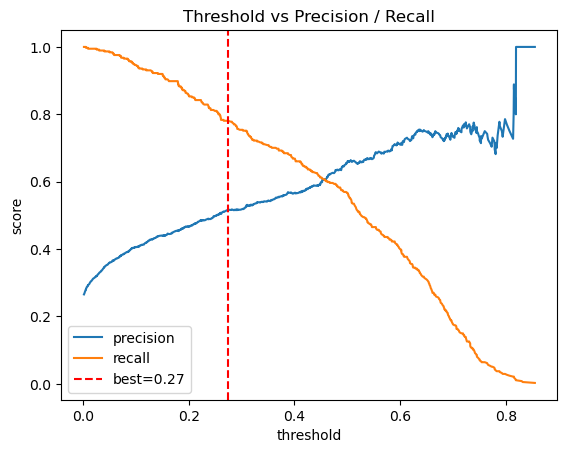

In [55]:
plt.plot(thresholds, precisions[:-1], label='precision')
plt.plot(thresholds, recalls[:-1], label='recall')
plt.axvline(thresholds[best_idx], color='red', linestyle='--', label=f'best={thresholds[best_idx]:.2f}')
plt.xlabel('threshold')
plt.ylabel('score')
plt.legend()
plt.title('Threshold vs Precision / Recall')
plt.show()

### グラフからわかること
- 閾値を下げる（左へ）と recall が上がり、precision が下がる（トレードオフ）
- 赤い点線（0.274）が、F1最大の点＝両者のバランスが取れた閾値
- この点より左に行けば recall はさらに上がるが、precision（＝空振りの少なさ）は犠牲になる

## 5. 解約要因の分析（SHAP）と施策提案

- ここまでで「誰が解約しそうか」は予測できるようになった
- 次は「**なぜ**解約するのか（何が効いているか）」をSHAPで分析する
- 予測に留めず、施策提案につなげることが目的

### SHAPによる要因分析
- SHAP：各特徴量が予測をどちら向きに・どれだけ動かしたかを定量化する手法
- 木系モデルには高速な TreeExplainer が使えるため、XGBoostで分析
- 「影響の大きさ」だけでなく「効く方向」まで可視化できる

In [56]:
# XGBoostを学習（SHAP可視化用）
xgb = XGBClassifier(eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)

# TreeExplainerでSHAP値を計算（木系なので高速）
# shap.TreeExplainer(xgb) … XGBoost専用の高速な説明器
# explainer.shap_values(X_test) … テストデータの各顧客・各特徴量について、「その特徴が予測をどれだけ動かしたか」を計算
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

print("SHAP値の計算完了")
print("shape:", shap_values.shape)

SHAP値の計算完了
shape: (1409, 30)


→ 全1409人 × 30特徴量のSHAP値を計算完了。次にこれを可視化する

### どの特徴量が解約予測に効いているか（重要度ランキング）
- 各特徴量が予測に与える影響の大きさを、棒グラフでランキング表示

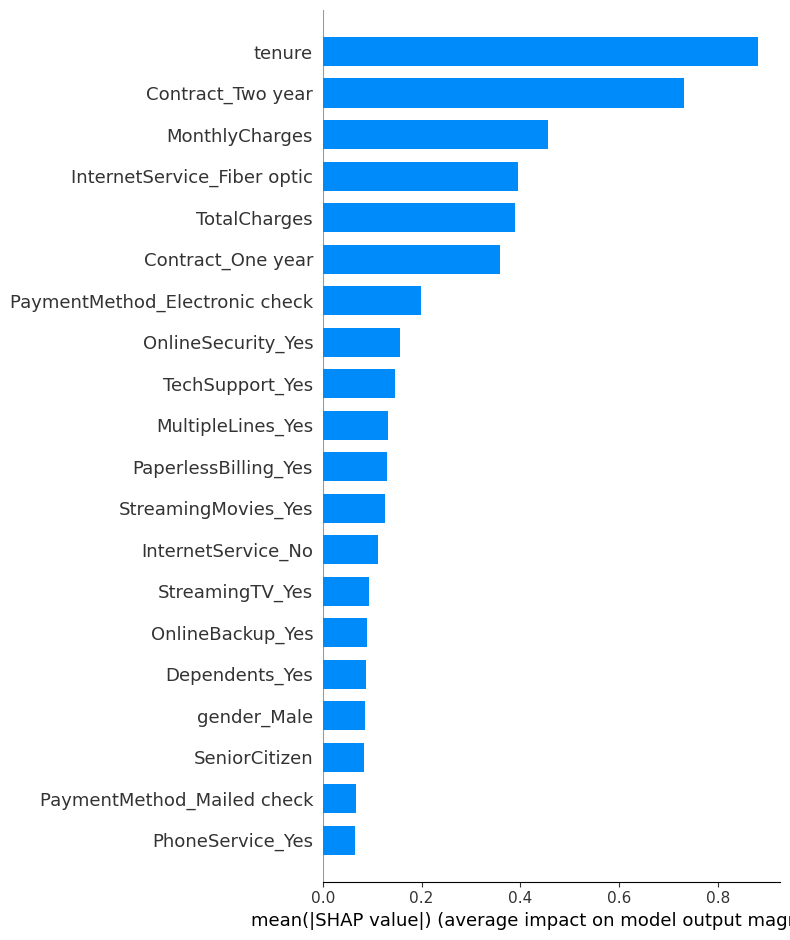

In [57]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

### わかること
- 上位は tenure（継続月数）・Contract（契約タイプ）・MonthlyCharges（月額料金）
- EDAで立てた仮説（継続月数・契約タイプが効く）と一致 → モデルの妥当性を確認
- ただしこの棒グラフは「影響の大きさ」のみ。「どちら向きに効くか」は次の詳細プロットで確認

### 各特徴量が「どちら向きに」効くか
- 横軸：右=解約方向、左=継続方向
- 色：赤=その特徴量の値が高い、青=低い
- 「値の高低」と「解約/継続方向」の関係から、解約要因を読み解く

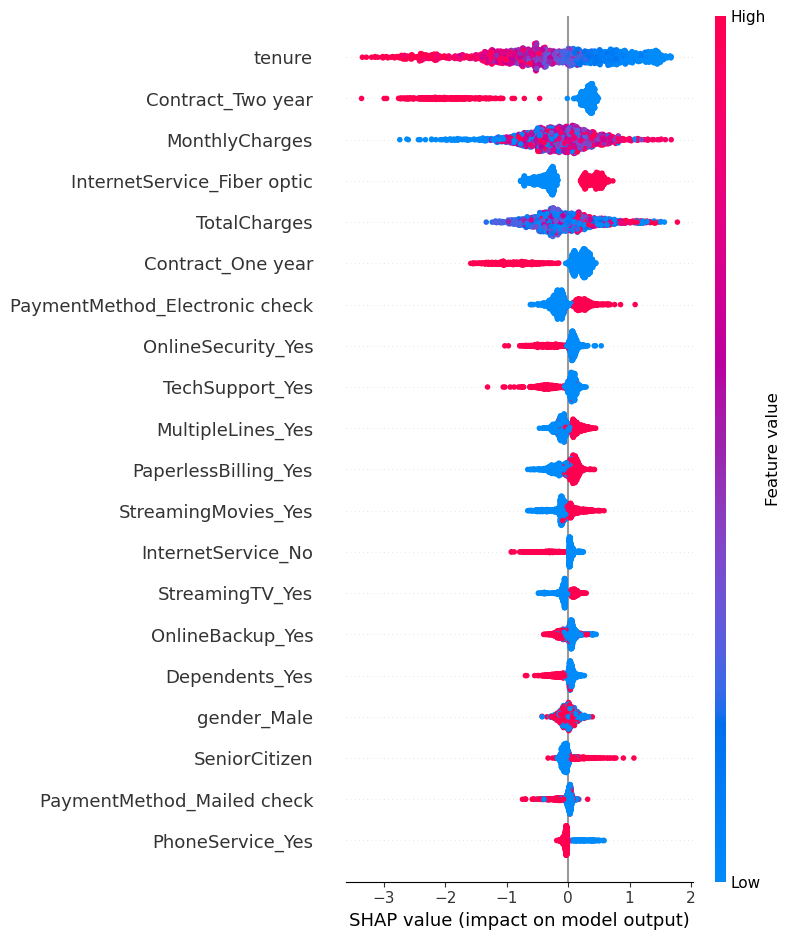

In [58]:
# 解約/継続どちらの方向に紐付きがあるかの可視化
shap.summary_plot(shap_values, X_test)

### 読み取れる解約要因
- **tenure（継続月数）**：短いほど解約しやすい（青が右）
- **Contract（2年契約）**：長期契約者は強く継続（赤が左）
- **MonthlyCharges（月額料金）**：高いほど解約しやすい（赤が右）
- **光ファイバー利用者**：解約しやすい
- **電子小切手払い**：解約しやすい
- **セキュリティ/サポート加入者**：継続しやすい（赤が左）

### 解約しやすい顧客像
契約したばかり（tenure短）・月契約または短期契約・月額料金が高い・光ファイバー利用・電子小切手払い・セキュリティ/サポート未加入 の顧客

### 施策提案
1. **契約初期の顧客を手厚くフォロー**（tenureが最大要因 → オンボーディング支援・初期特典）
2. **長期契約への誘導**（月契約層に割引付きで長期契約を促す）
3. **高額・光ファイバー層のケア**（料金プラン見直し・品質サポート強化）
4. **オプション加入の促進**（セキュリティ/サポート加入で継続率UP）

### 実行イメージ
- 閾値0.274で解約可能性の高い顧客を抽出（解約者の約75%を捕捉）し、上記施策を優先投下
- →閾値を0.274に調整しrecallを重視した(解約可能性のある人の見逃しを減らす方向にした。取りこぼしを減らすためのコストは低いと考えた)。通信業は顧客の生涯価値が高く、1人の解約損失が大きいため、多少の施策コスト増（precision低下）を許容してでも、解約者の取りこぼしを減らす方が合理的と判断した。ただし施策コストが高い場合は、precisionを重視して対象を絞る選択もあり得る
- 特に tenure の短い新規顧客層が最優先ターゲット

## 6. まとめ

- 通信会社の解約予測を、7モデル比較〜不均衡対策〜要因分析まで実施
- **モデル**：表形式・線形寄りのデータのため、シンプルなロジスティック回帰が最良
- **不均衡対策**：閾値調整により解約recallを0.56→0.75に改善（取りこぼし削減）
- **要因分析**：SHAPで、継続月数・契約タイプ・料金が主要因と特定（EDA仮説と一致）
- **施策提案**：新規顧客のフォロー・長期契約誘導など、具体的な打ち手を導出
- 単なる予測に留めず、「誰に・なぜ・何をすべきか」まで一気通貫で示した